In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.api as sm
from difflib import SequenceMatcher
import enum
import os

class Models(enum.Enum):
    MIXTRAL8_7 = "mixtral-8x7b-32768"
    MIXTRAL8_22 = 'mixtral-8x22b-65536'
    LLAMA3 = "llama3-70b-8192"
    GPT3_5 = "gpt-3.5-turbo"
    GPT4 = "gpt-4-turbo"
    GPT4o = "gpt-4o"

model_renames = {
    "mixtral-8x7b-32768": "mixtral-8x7b",
    "mixtral-8x22b-65536": "mixtral-8x22b",
    "llama3-70b-8192": "llama3-70b"
}

In [2]:
CWE_LIST = ["CWE-22", "CWE-89", "CWE-79"]

MODELS = [Models.MIXTRAL8_7, Models.MIXTRAL8_22, Models.LLAMA3, Models.GPT3_5, Models.GPT4o, Models.GPT4]
# MODELS = [Models.MIXTRAL8_7,  Models.GPT3_5]
# MODELS = [ Models.MIXTRAL8_7]
# MODELS = [Models.LLAMA3]

base_dir = "../../2_code_in_the_haystack/nith_cve_files"
BUGGY_FILES_FOLDER = f"{base_dir}/source_files"
MAX_CHARS = 250001

S = [4000,8000,16000,25000]

# Setup

## Definition of files

In [3]:
files_dict = {
    406: {
        "main_padding": "/php/406/406_whole.php",
        "buggy_content": "/php/406/406_smallestBuggy.php",
        "buggy_line": "$selectedIds = explode(',', $selectedIds);",
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    408: {
        'main_padding': '/php/408/408_whole.php',
        "additional_padding": ["/php/408/additional_padding.php"],
        "buggy_content": "/php/408/408_smallestBuggy.php",
        "buggy_line": '''SELECT * FROM ' . static::table_name() . ' WHERE ' . $property .  ''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    405: {
        'main_padding': '/php/405/405_whole.php',
        "additional_padding": ["/php/405/additional_padding.php"],
        "buggy_content": "/php/405/405_smallestBuggy.php",
        "buggy_line": '''$where = "WHERE group_ID = {$group_id}";''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    4921: {
        'main_padding': '/go/4921/4921_modifiedFile.go',
        "additional_padding": ["/go/4921/additional_padding.go"],
        "buggy_content": "/go/4921/4921_smallestBuggy.go",
        "buggy_line": '''order := fmt.Sprintf("`%s` %s", DefaultQuery(c, "sort_by", "id"), sort)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    4928: {
        'main_padding': '/php/4928/4928_modifiedFile.php',
        "additional_padding": ["/php/4928/additional_padding.php"],
        "buggy_content": "/php/4928/4928_smallestBuggy.php",
        "buggy_line": '''return @mysqli_real_escape_string($fmdb->dbh, $data);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    3989:{
        'main_padding': '/js/3989/3989_whole.js',
        "additional_padding": ["/js/3989/additional_padding.js"],
        "buggy_content": "/js/3989/3989_smallestBuggy.js",
        "buggy_line": '''`window[${idJSON}].push(${serializedCacheArgs});`,''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    3976:{
        'main_padding': '/js/3976/3976_whole.js',
        "additional_padding": ["/js/3976/additional_padding.js"],
        "buggy_content": "/js/3976/3976_smallestBuggy.js",
        "buggy_line": '''const header = container.querySelector(`h${level}`);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    3968:{
        'main_padding': '/php/3968/3968_whole.php',
        "additional_padding": ["/php/3968/additional_padding.php"],
        "buggy_content": "/php/3968/3968_smallestBuggy.php",
        "buggy_line": '''$response['data']['path'] = $model->path;''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    300:{
        'main_padding': '/php/300/300_modifiedFile.php',
        "additional_padding": ["/php/300/additional_padding.php"],
        "buggy_content": "/php/300/300_smallestBuggy.php",
        "buggy_line": '''<td>' . $item->id . '</td>''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    302:{
        'main_padding': '/rb/302/302_modifiedFile.rb',
        "additional_padding": ["/rb/302/additional_padding.rb"],
        "buggy_content": "/rb/302/302_smallestBuggy.rb",
        "buggy_line": '''@filter = params[:filter] || "*"''',
        "split_string": "# -x-",
        "CWE_ID": "CWE-79"
    },
    5422:{
        'main_padding': '/go/5422/5422_modifiedFile.go',
        "additional_padding": ["/go/5422/additional_padding.go"],
        "buggy_content": "/go/5422/5422_smallestBuggy.go",
        "buggy_line": '''outdir := filepath.Join(basePath, name)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5396:{
        'main_padding': '/java/5396/5396_modifiedFile.java',
        "additional_padding": ["/java/5396/additional_padding.java"],
        "buggy_content": "/java/5396/5396_smallestBuggy.java",
        "buggy_line": '''URI uri = toURI(fileUri);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5404:{
        'main_padding': '/go/5404/5404_modifiedFile.go',
        "additional_padding": ["/go/5404/additional_padding.go"],
        "buggy_content": "/go/5404/5404_smallestBuggy.go",
        "buggy_line": '''target := filepath.Join(dst, name)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5414:{
        'main_padding': '/js/5414/5414_modifiedFile.js',
        "additional_padding": ["/js/5414/additional_padding.js"],
        "buggy_content": "/js/5414/5414_smallestBuggy.js",
        "buggy_line": '''var filename = path.join(__dirname, "public", req.url.path_list.join("/"));''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    493:{
        'main_padding': '/py/493/493_modifiedFile.py',
        "additional_padding": ["/py/493/additional_padding.py"],
        "buggy_content": "/py/493/493_smallestBuggy.py",
        "buggy_line": '''return FileResponse(f"user_images/pfp/{username}", media_type='image/gif')''',
        "split_string": "# -x-",
        "CWE_ID": "CWE-22"
    },
}

## Import CSV

In [4]:
def import_csv(cwe_list, models, files_path, inference_results_folder):
    df_files = pd.read_csv(files_path)
    df_files = df_files[df_files['target_length'] <= MAX_CHARS]

    combined_df = pd.DataFrame()

    for model in models:
        df_model = pd.read_csv(inference_results_folder+"/"+model.value+".csv")
        for cwe_id in cwe_list:

            # print(f"Processing CWE {cwe_id} for model {model}")
            df_cwe = df_files[(df_files['CWE_ID'] == cwe_id)]

            if len(df_cwe) == 0:
                # print(f"No files found for CWE {cwe_id}")
                continue

            df_combined = pd.merge(df_model, df_cwe, on='file_id', how='inner')

            _check_files(df_model, df_cwe)


            combined_df = pd.concat([combined_df, df_combined])

    combined_df = combined_df[['content', 'model_output', 'prompt', 'file_id', 'database_file_id', 'length', 'bug_position', 'target_bug_position', 'target_length', 'CWE_ID', 'model']]
    
    return combined_df

# Check files function
def _check_files(df_data, df_files):
    file_ids_data = df_data['file_id'].value_counts()
    file_ids_files = df_files['file_id'].unique()

    problems = []
    for file_id in file_ids_files:
        if file_id not in file_ids_data or file_ids_data[file_id] != 1:
            problems.append(file_id)
        
    # if len(df_data) != len(df_files):
        # print(f"Data count mismatch: Expected {len(df_files)}, got {len(df_data)}.")

    # if problems:
    #     print(f"Some file_ids are missing the required number of entries in the data:")
    #     for file_id in problems:
    #         count = file_ids_data[file_id] if file_id in file_ids_data else 0
    # else:
    #     print("All file_ids have the correct number of entries.")


## Extracting functions for classification

In [5]:
def extract_code_or_return_original(text):
    pattern = r"```([a-zA-Z]+)\n(.*?)```"
    matches = list(re.finditer(pattern, text, re.DOTALL))

    if not matches:
        return text

    results = []
    for match in matches:
        results.append(match.group(2).strip())

    return "\n".join(results)

def clean_whitespace(text):
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip().strip('`.')

def remove_spaces(text):
    return text.replace(' ', '')

def get_removed_lines(patch):
    removed_lines = re.findall(r'^-.*$', patch, re.MULTILINE)
    removed_lines = [line[1:] for line in removed_lines]
    return ' '.join(removed_lines)

def extract_bug_line(model_output):
    bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
    bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)

    if(len(re.split(bug_line_pattern, model_output)) < 3):
        bug_line = re.split(bug_line_pattern_simple, model_output)[-1].strip()
    else:
        bug_line = re.split(bug_line_pattern, model_output)[-2].strip()

    bug_line = extract_code_or_return_original(bug_line).strip()

    match = re.search(r'`([^`]+)`', bug_line)
    if match:
        bug_line =  match.group(0)

    bug_line = clean_whitespace(bug_line)
    return bug_line
    
def has_bug_line(model_output):
    code = extract_code_or_return_original(model_output)

    bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
    bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)

    _has_bug_line = bool(bug_line_pattern.search(model_output))

    if not _has_bug_line:
        return False
    
    bug_line = extract_bug_line(model_output)
    bug_line = remove_spaces(clean_whitespace(bug_line)).strip()

    if(len(bug_line) == 0):
        return False

    if(_has_bug_line and ('BL: None'.lower() not in model_output.lower() or "BUG FOUND: NO".lower() not in model_output.lower())):
        return True
    
    if code and code != model_output:
        return True

# Clean patch function
def clean_patch(patch):
    return re.sub(r'^[+-]', '', patch, flags=re.MULTILINE)

In [6]:
def load_buggy_file(filepath):
    with open(BUGGY_FILES_FOLDER+filepath, 'r') as file:
        return file.read()

In [7]:
def classify(record, file_dict):
    model_output = record['model_output']

    classification = None
    bug_line = None
    bug_line_in_content = False

    pattern_yes = re.compile(r"bug\s*found\s*:\s*yes", re.IGNORECASE)
    pattern_no = re.compile(r"bug\s*found\s*:\s*no", re.IGNORECASE)

    # Check for matches
    has_bug_true_indication = bool(re.search(pattern_yes, model_output))
    has_bug_false_indication = bool(re.search(pattern_no, model_output))
    _has_bug_line = has_bug_line(model_output)

    # stronger conditions -> lets rely purely on model_output under Bug found
    if type == 'not_buggy':
        if has_bug_true_indication: 
            classification = 'FP'
        else:
            classification = 'TN'
    elif type == 'buggy' and has_bug_false_indication: 
        classification = 'FN'
    else:
        # weaker decision based in bugged_line
        if not _has_bug_line:
            classification = 'FN'
        else:
            bug_line = remove_spaces(extract_bug_line(model_output))
            # patch_removal = remove_spaces(clean_whitespace(get_removed_lines(patch)))
            cleaned_patch = remove_spaces(clean_whitespace(clean_patch(load_buggy_file(file_dict[record['database_file_id']]['buggy_content']))))

            bug_line_in_patch = bug_line in cleaned_patch

            if (len(bug_line) > 0 and bug_line_in_patch):
                classification = 'TP'
            else:
                classification = 'FN' 
        
    return pd.Series([classification, bug_line])

# Prepare dataframe function
def prepare_df(df, file_dict):
    df[['classification', 'bug_line']] = df.apply(lambda record: classify(record, file_dict), axis=1)
    return df

# Load Data

In [8]:
runs = {
    'run1': {
        'files': f'{base_dir}/files.csv',
        'inference': f'{base_dir}/run1/inference'
    },
    'run2': {
        'files': f'{base_dir}/files.csv',
        'inference': f'{base_dir}/run2/inference'
    },
    'run3': {
        'files': f'{base_dir}/files.csv',
        'inference': f'{base_dir}/run3/inference'
    },
    'run4': {
        'files': f'{base_dir}/files.csv',
        'inference': f'{base_dir}/run4/inference'
    },
    'run5': {
        'files': f'{base_dir}/files.csv',
        'inference': f'{base_dir}/run5/inference'
    }
    
}
df_total = pd.DataFrame()
for run in runs:
    files_path = runs[run]['files']
    inference_results_folder = runs[run]['inference']
    combined_df = import_csv(CWE_LIST, MODELS, files_path, inference_results_folder)
    df = prepare_df(combined_df, files_dict)
    # add run column
    df['run'] = run
    df_total = pd.concat([df_total, df])

# Logistic Regression

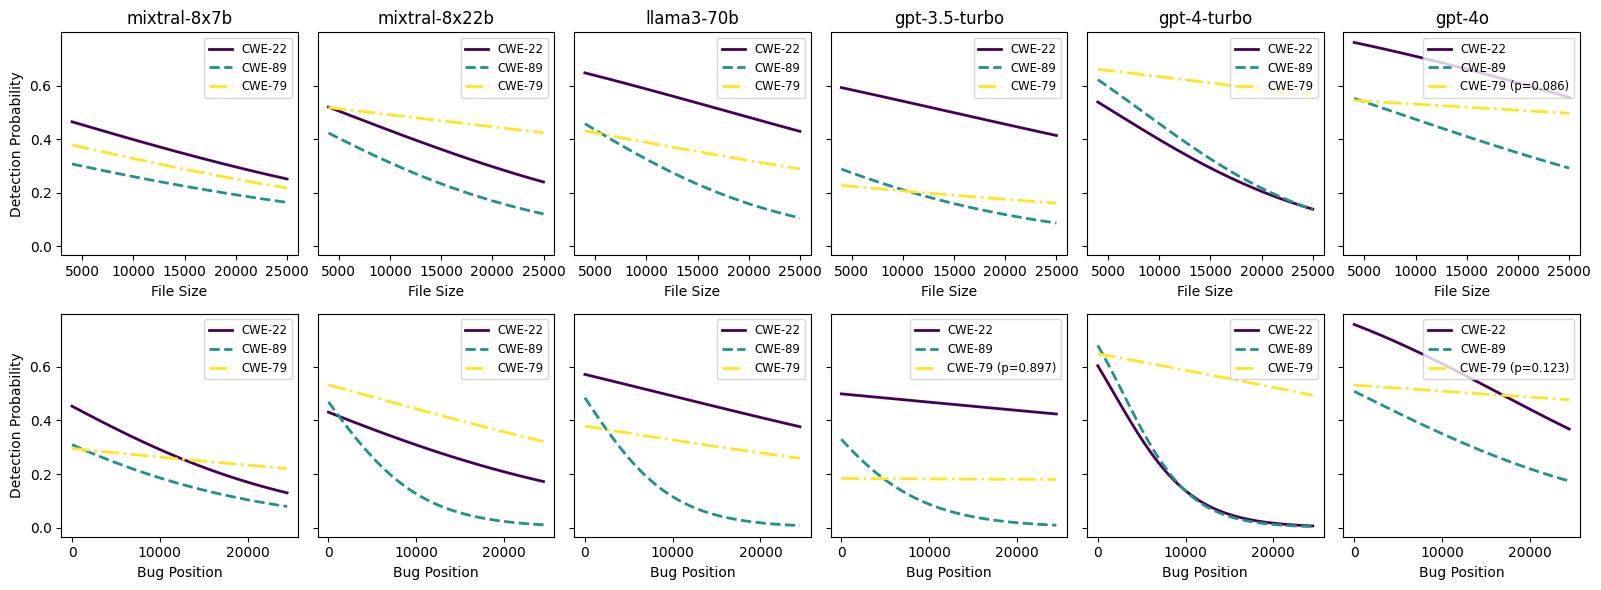

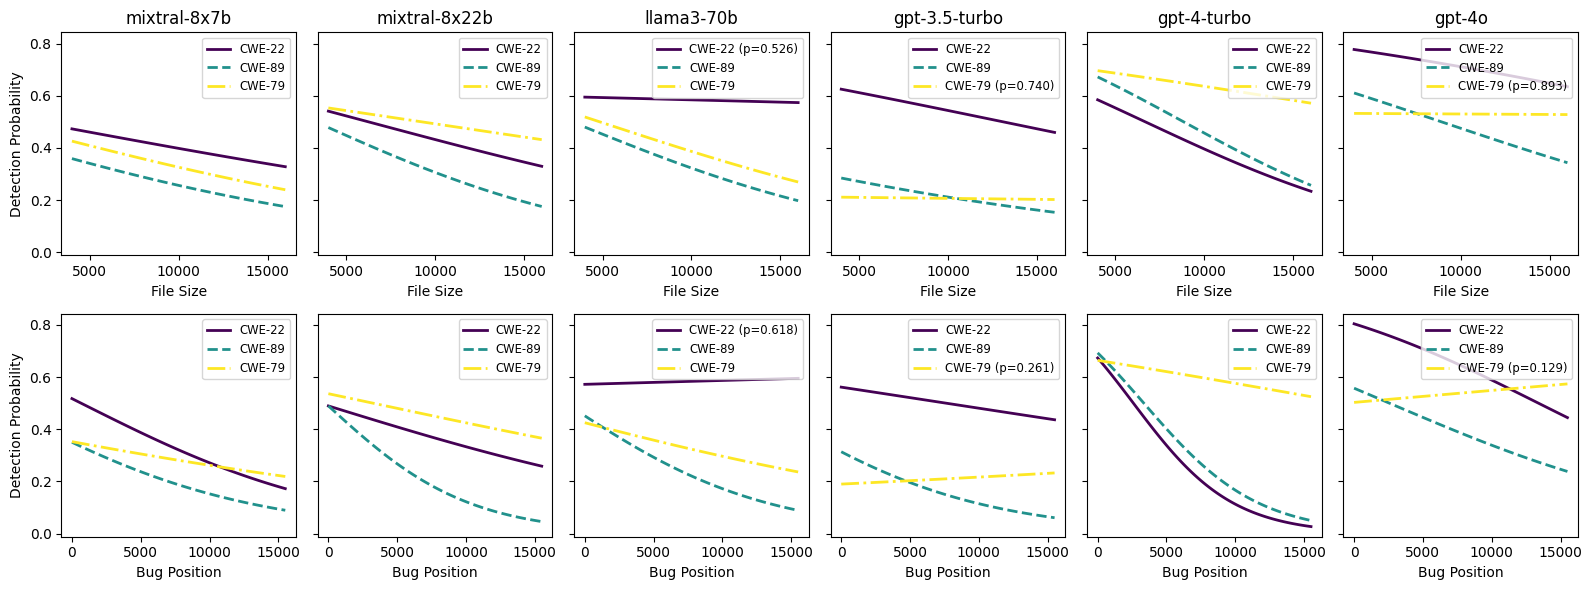

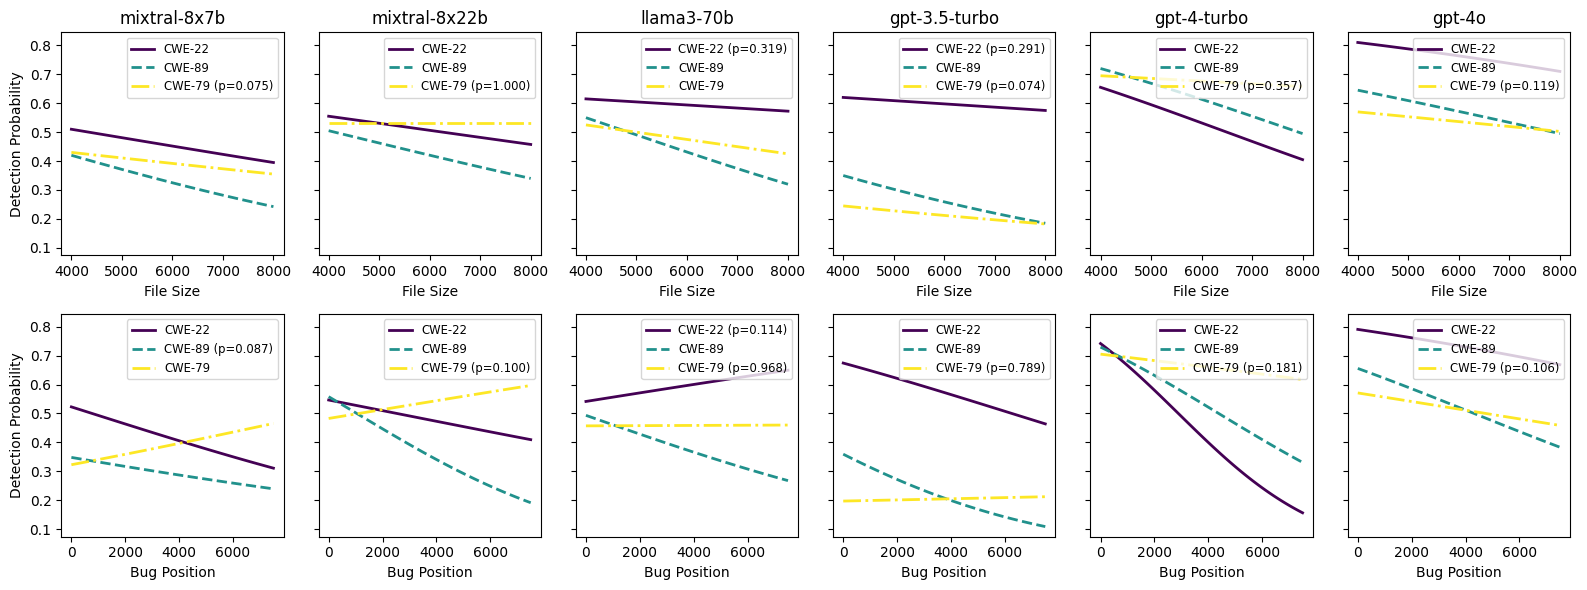

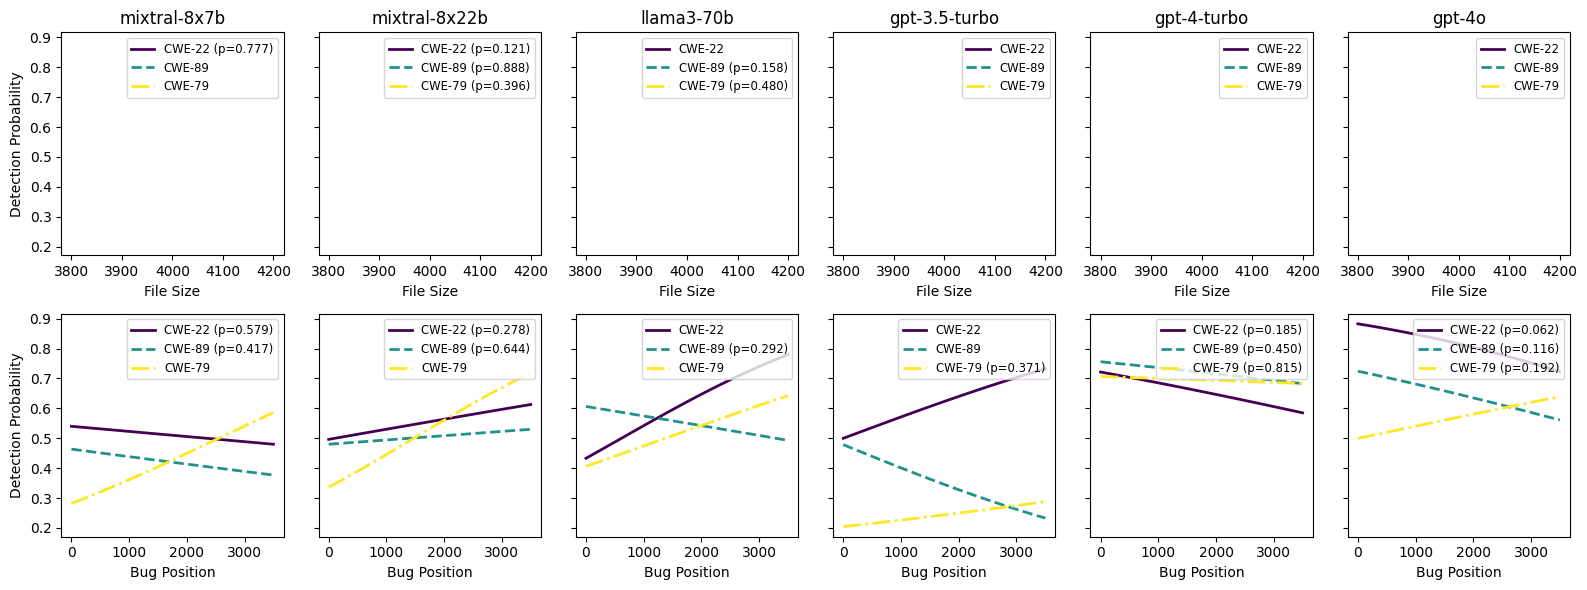

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Logistic Regression Plotting Functions
def plot_logistic_regressions_for_all_models(df, models, features, cwe_ids, save_path='./', filename='logistic_regression_all_models'):
    # Prepare the classification column for logistic regression
    df = df[df['classification'].isin(['TP', 'FN'])]
    df['classification_TP'] = df['classification'].apply(lambda x: 1 if x == 'TP' else 0)

    fig, axes = plt.subplots(nrows=len(features), ncols=len(models), figsize=(8 * len(features), len(models)), dpi=100, sharex='row', sharey='all')
    fig.subplots_adjust(hspace=0.4, wspace=0.3)  # Adjust spacing between plots
    colors = plt.cm.viridis(np.linspace(0, 1, len(cwe_ids)))  # Generate a color array

    for row, feature in enumerate(features):
        for col, model in enumerate(models):
            ax = axes[row, col] if len(features) > 1 else axes
            for cwe_id, color in zip(cwe_ids, colors):
                cwe_df = df[(df['CWE_ID'] == cwe_id) & (df['model'] == model.value)]
                if not cwe_df.empty:
                    has_hit_threshold = plot_logistic_regression(cwe_df, feature, 'classification_TP', cwe_id, ax, color)
                    if has_hit_threshold:
                        print("threshold hit:", cwe_id, filename)
            feature_label = 'Bug Position' if feature=='target_bug_position' else 'File Size'
            if col == 0:  # Set Y-axis labels for the first column only
                ax.set_ylabel("Detection Probability")
            ax.set_xlabel(feature_label)
            ax.legend(loc='upper right', fontsize='small')

            # Optionally set titles for the first row, or adjust according to your needs
            if row == 0:
                # Renaming models
                ax.set_title(model_renames.get(model.value,model.value))

    #fig.suptitle(f'Logistic Regression Analysis Across CWEs for All Models', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(save_path,f"{filename}.pdf"))
    plt.show()

def plot_logistic_regression(data, x_col, y_col, label, ax, color):
    X = sm.add_constant(data[x_col])
    y = data[y_col]
    model = sm.Logit(y, X).fit(disp=0)
    x_values = np.linspace(data[x_col].min(), data[x_col].max(), 100)
    y_probs = model.predict(sm.add_constant(x_values))
    
    label_dict = {
        "CWE-22": "CWE-22",
        "CWE-89": "CWE-89",
        "CWE-79": "CWE-79"
    }
    
    # Define line styles for each CWE for differentiation
    line_styles = {
        'CWE-22': 'solid',  # solid line
        'CWE-89': 'dashed', # dashed line
        'CWE-79': 'dashdot' # dash-dot line
    }
    _label = label_dict.get(label, label) + (f" (p={model.pvalues[x_col]:.3f})" if model.pvalues[x_col] > 0.05 else "")
    ax.plot(x_values, y_probs, linestyle=line_styles[label], label=_label, color=color, linewidth=2)
    return x_col == 'feature' and model.pvalues['feature'] > 0.05

# Example usage
models = [Models.MIXTRAL8_7, Models.MIXTRAL8_22, Models.LLAMA3, Models.GPT3_5, Models.GPT4, Models.GPT4o]  # Example Models

# Filtering the dataframe to include only relevant rows for logistic regression
# df_filtered = df[(df['classification'] == 'TP') | (df['classification'] == 'FN')]
df_filtered = df_total
df_filtered = df_filtered.dropna(subset=['target_length', 'target_bug_position'])  # Ensure no NaN values in necessary columns

for size_threshold in reversed(S):
    #df_filtered = df_filtered[df_filtered['target_bug_position'] <= size_threshold]
    df_filtered = df_filtered[df_filtered['target_length'] <= size_threshold]

    # Plotting logistic regression for each model in a single plot
    plot_logistic_regressions_for_all_models(
        df_filtered, 
        models, 
        ['target_length', 'target_bug_position'], 
        CWE_LIST,
        filename=f'logistic_regression_t={size_threshold}'
    )
